# Objective 1B: RJDB External Validation

This notebook uses the RJDB dataset as an external validation dataset for Objective 1. It checks whether TF-IDF, DistilBERT, SBERT and Hybrid give a higher score to the matched resume compared to the unmatched resume for the same job description.

In [2]:
# Install packages if needed
!pip -q install pandas numpy scikit-learn sentence-transformers transformers torch matplotlib

In [3]:
import os
import re
import json
import zipfile
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import torch
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

# Change this path if your file is in another folder
RJDB_ZIP_PATH = "rjdb-main.zip"
RJDB_FOLDER = "rjdb-main"
RJDB_TEST_PATH = os.path.join(RJDB_FOLDER, "data", "test.jsonl")

# Number of samples used for validation. Increase later if needed.
SAMPLE_SIZE = 200
RANDOM_STATE = 42

# Hybrid model weightage used in the main project
TFIDF_WEIGHT = 0.7
SBERT_WEIGHT = 0.3

# Keep this True if you want to compare DistilBERT also.
# If your laptop is slow, set it to False first.
RUN_DISTILBERT = True

In [4]:
# Extract RJDB zip if the folder is not available
if not os.path.exists(RJDB_TEST_PATH):
    if os.path.exists(RJDB_ZIP_PATH):
        with zipfile.ZipFile(RJDB_ZIP_PATH, "r") as z:
            z.extractall(".")
        print("RJDB zip extracted.")
    else:
        raise FileNotFoundError(
            "Cannot find rjdb-main.zip. Put the RJDB zip file in the same folder as this notebook."
        )

print("Using RJDB test file:", RJDB_TEST_PATH)

RJDB zip extracted.
Using RJDB test file: rjdb-main\data\test.jsonl


In [5]:
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

rjdb_df = load_jsonl(RJDB_TEST_PATH)
print("Total RJDB test rows:", len(rjdb_df))
print("Columns:", rjdb_df.columns.tolist())
rjdb_df.head(2)

Total RJDB test rows: 1000
Columns: ['Job-Description', 'Resume-matched', 'Resume-unmatched', 'Skills', 'Experiences', 'Experiences-years', 'Filtered-information']


,Job-Description,Resume-matched,Resume-unmatched,Skills,Experiences,Experiences-years,Filtered-information
0,\n\n## Job title\nJunior Systems Admin/Enginee...,\n\n## Personal Information\nName: Azaria Wats...,\n\n## Personal Information\nName: Azaria Wats...,"[Analysis, Audio Visual, Customer Service, Dia...","[Junior Systems Admin/Engineer, SOC Security A...","[[[4 years as a Junior Systems Admin/Engineer,...","{'Skills': ['Customer Service', 'Networking'],..."
1,\n\n## Job title\nSurvey Researchers\n\n## Job...,\n\n## Personal Information\n**Name:** Joel Pe...,\n\n## Personal Information\n**Name:** Joel Pe...,"[Manual Dexterity, Physical Strength and Stami...","[Tire repairers and changers, Insulation worke...","[[[3 years as a Survey researchers, 5 years as...","{'Skills': ['Physical Strength and Stamina', '..."


In [6]:
# Basic cleaning for job and resume text
def clean_text(t):
    t = str(t)
    t = re.sub(r"\r", "\n", t)
    t = re.sub(r"\n{2,}", "\n", t)
    t = re.sub(r"[ \t]+", " ", t)
    return t.strip()

required_cols = ["Job-Description", "Resume-matched", "Resume-unmatched"]
for col in required_cols:
    if col not in rjdb_df.columns:
        raise ValueError(f"Missing column: {col}")

rjdb_df = rjdb_df.dropna(subset=required_cols).copy()
for col in required_cols:
    rjdb_df[col] = rjdb_df[col].apply(clean_text)
    rjdb_df = rjdb_df[rjdb_df[col].str.len() > 20]

# Use a fixed sample to keep the experiment fast and repeatable
sample_n = min(SAMPLE_SIZE, len(rjdb_df))
sample_df = rjdb_df.sample(n=sample_n, random_state=RANDOM_STATE).reset_index(drop=True)

print("Rows used for validation:", len(sample_df))
sample_df[["Job-Description", "Resume-matched", "Resume-unmatched"]].head(1)

Rows used for validation: 200


,Job-Description,Resume-matched,Resume-unmatched
0,## Job title\nCapacity Planner / Infrastructur...,## Personal Information\nName: Stella Warren\n...,## Personal Information\nName: Stella Warren\n...


In [7]:
def pairwise_accuracy(matched_scores, unmatched_scores):
    matched_scores = np.array(matched_scores)
    unmatched_scores = np.array(unmatched_scores)
    return (matched_scores > unmatched_scores).mean() * 100

def summarize_model(model_name, matched_scores, unmatched_scores, runtime_sec):
    matched_scores = np.array(matched_scores)
    unmatched_scores = np.array(unmatched_scores)
    diff = matched_scores - unmatched_scores
    return {
        "Model": model_name,
        "Avg Matched Score": round(float(matched_scores.mean()), 4),
        "Avg Unmatched Score": round(float(unmatched_scores.mean()), 4),
        "Avg Score Difference": round(float(diff.mean()), 4),
        "Pairwise Accuracy (%)": round(float(pairwise_accuracy(matched_scores, unmatched_scores)), 2),
        "Runtime (sec)": round(float(runtime_sec), 2)
    }

In [8]:
# TF-IDF validation
# Fit one TF-IDF vectorizer on all job and resume texts in the sample.
t0 = time.time()
all_texts = (
    sample_df["Job-Description"].tolist()
    + sample_df["Resume-matched"].tolist()
    + sample_df["Resume-unmatched"].tolist()
)

tfidf_vec = TfidfVectorizer(stop_words="english", max_features=30000, ngram_range=(1, 2))
X = tfidf_vec.fit_transform(all_texts)

n = len(sample_df)
job_vecs = X[0:n]
matched_vecs = X[n:2*n]
unmatched_vecs = X[2*n:3*n]

tfidf_matched = []
tfidf_unmatched = []
for i in range(n):
    tfidf_matched.append(cosine_similarity(job_vecs[i], matched_vecs[i]).flatten()[0])
    tfidf_unmatched.append(cosine_similarity(job_vecs[i], unmatched_vecs[i]).flatten()[0])

tfidf_time = time.time() - t0
print("TF-IDF completed.")
print("Pairwise Accuracy:", round(pairwise_accuracy(tfidf_matched, tfidf_unmatched), 2), "%")

TF-IDF completed.
Pairwise Accuracy: 88.5 %


In [9]:
# DistilBERT validation
# This follows the same idea as the original Objective 1 BERT comparison.
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

@torch.no_grad()
def encode_distilbert(texts, tokenizer, model, batch_size=16, max_length=256):
    embeddings = []
    device = next(model.parameters()).device
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        output = model(**encoded)
        emb = mean_pooling(output, encoded["attention_mask"])
        emb = torch.nn.functional.normalize(emb, p=2, dim=1)
        embeddings.append(emb.cpu().numpy())
    return np.vstack(embeddings)

if RUN_DISTILBERT:
    t0 = time.time()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    bert_name = "distilbert-base-uncased"
    bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
    bert_model = AutoModel.from_pretrained(bert_name).to(device)
    bert_model.eval()

    bert_all_vecs = encode_distilbert(all_texts, bert_tokenizer, bert_model, batch_size=16, max_length=256)
    bert_job = bert_all_vecs[0:n]
    bert_matched = bert_all_vecs[n:2*n]
    bert_unmatched = bert_all_vecs[2*n:3*n]

    bert_matched_scores = np.sum(bert_job * bert_matched, axis=1)
    bert_unmatched_scores = np.sum(bert_job * bert_unmatched, axis=1)
    bert_time = time.time() - t0

    print("DistilBERT completed.")
    print("Pairwise Accuracy:", round(pairwise_accuracy(bert_matched_scores, bert_unmatched_scores), 2), "%")
else:
    bert_matched_scores = None
    bert_unmatched_scores = None
    bert_time = 0
    print("DistilBERT skipped.")

Device: cpu
DistilBERT completed.
Pairwise Accuracy: 87.5 %


In [10]:
# SBERT validation
# Same SBERT model used in Objective 1.
t0 = time.time()
sbert_name = "sentence-transformers/all-mpnet-base-v2"
print("Loading SBERT:", sbert_name)
sbert = SentenceTransformer(sbert_name)

sbert_all_vecs = sbert.encode(
    all_texts,
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=16,
    show_progress_bar=True
)

sbert_job = sbert_all_vecs[0:n]
sbert_matched_vecs = sbert_all_vecs[n:2*n]
sbert_unmatched_vecs = sbert_all_vecs[2*n:3*n]

sbert_matched = np.sum(sbert_job * sbert_matched_vecs, axis=1)
sbert_unmatched = np.sum(sbert_job * sbert_unmatched_vecs, axis=1)
sbert_time = time.time() - t0

print("SBERT completed.")
print("Pairwise Accuracy:", round(pairwise_accuracy(sbert_matched, sbert_unmatched), 2), "%")

Loading SBERT: sentence-transformers/all-mpnet-base-v2


Batches:   0%|          | 0/38 [00:00<?, ?it/s]

SBERT completed.
Pairwise Accuracy: 69.5 %


In [11]:
# Hybrid validation
# Hybrid score follows the project formula: 0.7 TF-IDF + 0.3 SBERT
hybrid_matched = (TFIDF_WEIGHT * np.array(tfidf_matched)) + (SBERT_WEIGHT * np.array(sbert_matched))
hybrid_unmatched = (TFIDF_WEIGHT * np.array(tfidf_unmatched)) + (SBERT_WEIGHT * np.array(sbert_unmatched))

print("Hybrid completed.")
print("Pairwise Accuracy:", round(pairwise_accuracy(hybrid_matched, hybrid_unmatched), 2), "%")

Hybrid completed.
Pairwise Accuracy: 88.5 %


In [12]:
# Summary table
summary_rows = []
summary_rows.append(summarize_model("TF-IDF", tfidf_matched, tfidf_unmatched, tfidf_time))

if RUN_DISTILBERT:
    summary_rows.append(summarize_model("DistilBERT", bert_matched_scores, bert_unmatched_scores, bert_time))

summary_rows.append(summarize_model("SBERT", sbert_matched, sbert_unmatched, sbert_time))
summary_rows.append(summarize_model("Hybrid (0.7 TF-IDF + 0.3 SBERT)", hybrid_matched, hybrid_unmatched, tfidf_time + sbert_time))

summary_df = pd.DataFrame(summary_rows)
summary_df

,Model,Avg Matched Score,Avg Unmatched Score,Avg Score Difference,Pairwise Accuracy (%),Runtime (sec)
0,TF-IDF,0.3281,0.2546,0.0735,88.5,0.40
1,DistilBERT,0.9441,0.9317,0.0125,87.5,62.22
2,SBERT,0.7410,0.7029,0.0381,69.5,109.64
3,Hybrid (0.7 TF-IDF + 0.3 SBERT),0.4520,0.3891,0.0629,88.5,110.04


In [13]:
# Detailed result for every RJDB pair
detail_df = pd.DataFrame({
    "row_id": sample_df.index,
    "job_description": sample_df["Job-Description"],
    "tfidf_matched_score": tfidf_matched,
    "tfidf_unmatched_score": tfidf_unmatched,
    "tfidf_correct": np.array(tfidf_matched) > np.array(tfidf_unmatched),
    "sbert_matched_score": sbert_matched,
    "sbert_unmatched_score": sbert_unmatched,
    "sbert_correct": np.array(sbert_matched) > np.array(sbert_unmatched),
    "hybrid_matched_score": hybrid_matched,
    "hybrid_unmatched_score": hybrid_unmatched,
    "hybrid_correct": np.array(hybrid_matched) > np.array(hybrid_unmatched),
})

if RUN_DISTILBERT:
    detail_df["distilbert_matched_score"] = bert_matched_scores
    detail_df["distilbert_unmatched_score"] = bert_unmatched_scores
    detail_df["distilbert_correct"] = np.array(bert_matched_scores) > np.array(bert_unmatched_scores)

detail_df.head(10)

,row_id,job_description,tfidf_matched_score,tfidf_unmatched_score,tfidf_correct,sbert_matched_score,sbert_unmatched_score,sbert_correct,hybrid_matched_score,hybrid_unmatched_score,hybrid_correct,distilbert_matched_score,distilbert_unmatched_score,distilbert_correct
0,0,## Job title\nCapacity Planner / Infrastructur...,0.280113,0.221502,True,0.593664,0.656163,False,0.374178,0.351900,True,0.953864,0.937313,True
1,1,## Job title\nEnterprise Systems Engineer\n## ...,0.232518,0.169169,True,0.777828,0.800204,False,0.396111,0.358479,True,0.948011,0.950623,False
2,2,## Job Title\nSoftware Test Automation Expert ...,0.370600,0.086366,True,0.798987,0.570573,True,0.499116,0.231628,True,0.942895,0.909619,True
3,3,## Job title\nSalesforce Consultant\n## Job Su...,0.268668,0.275772,False,0.755465,0.723414,True,0.414707,0.410065,True,0.963104,0.946258,True
4,4,"## Job Title\nDispatcher (Excluding Police, Fi...",0.232391,0.170629,True,0.578326,0.591306,False,0.336172,0.296832,True,0.941964,0.908822,True
5,5,## Job title\nSteamfitters and Pipefitters\n##...,0.209041,0.135534,True,0.776908,0.824118,False,0.379401,0.342109,True,0.936469,0.935348,True
6,6,## Job Title\nTransit and Railroad Police\n## ...,0.208002,0.177563,True,0.760880,0.668464,True,0.373866,0.324834,True,0.944022,0.955231,False
7,7,## Job title\nDirector - Quality Engineering \...,0.197299,0.223593,False,0.779913,0.795536,False,0.372083,0.395176,False,0.964648,0.955121,True
8,8,## Job title\nDevelopment Manager - MATLAB Liv...,0.317575,0.297979,True,0.557604,0.547121,True,0.389584,0.372722,True,0.935253,0.937910,False
9,9,## Job title\nHadoop DBA / Developer\n## Job S...,0.392473,0.366716,True,0.870199,0.879068,False,0.535791,0.520421,True,0.966220,0.956734,True


In [14]:
# Save outputs for report and dashboard evidence
summary_df.to_csv("rjdb_external_validation_summary.csv", index=False)
detail_df.to_csv("rjdb_external_validation_detailed.csv", index=False)

print("Saved files:")
print("- rjdb_external_validation_summary.csv")
print("- rjdb_external_validation_detailed.csv")

Saved files:
- rjdb_external_validation_summary.csv
- rjdb_external_validation_detailed.csv


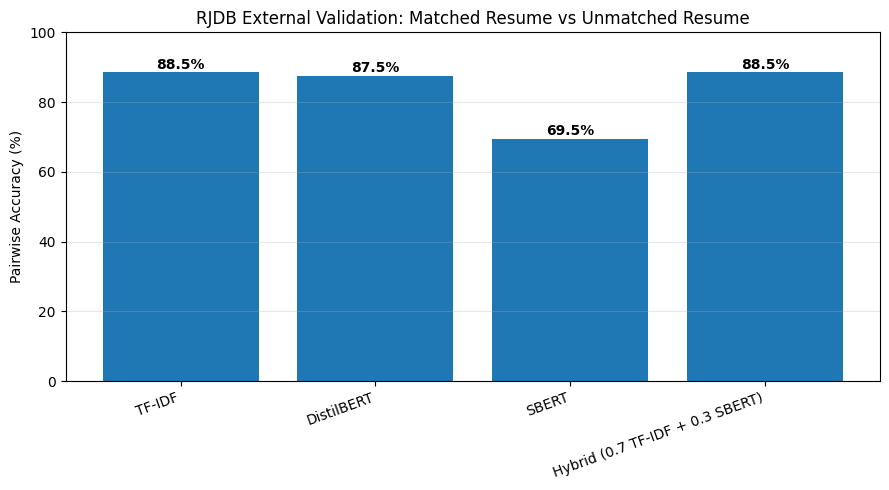

In [15]:
# Visualization
plt.figure(figsize=(9, 5))
plt.bar(summary_df["Model"], summary_df["Pairwise Accuracy (%)"])
plt.ylabel("Pairwise Accuracy (%)")
plt.title("RJDB External Validation: Matched Resume vs Unmatched Resume")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(summary_df["Pairwise Accuracy (%)"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("rjdb_external_validation_accuracy.png", dpi=200)
plt.show()

## How to write this in the report

RJDB was used as an external validation dataset for Objective 1 because it contains job descriptions with matched and unmatched resumes. The experiment checks whether each model gives a higher similarity score to the matched resume compared to the unmatched resume. Pairwise accuracy is calculated as the percentage of cases where the matched resume score is higher than the unmatched resume score. This supports the model comparison with an external benchmark dataset from the literature.